# 3D Solute-in-LJ-Bath: E(n)-Equivariant Flow with PBC

This notebook trains an **E(n)-equivariant normalizing flow** for the 3D solute-in-LJ-bath system with **periodic boundary conditions (PBC)**.

Key differences from the non-equivariant version:
- **No Hungarian preprocessing** — permutation symmetry is handled by the EGNN architecture
- **PBC** — minimum-image convention instead of soft harmonic walls
- **E(n)-equivariant coupling layers**:
  - `RadialCouplingLayer`: EGNN-conditioned RQ spline on `log(r_i)` (distance from solute)
  - `AngularCouplingLayer`: EGNN equivariant Rodrigues rotation of direction `u_i`

**Architecture summary:**
- 36 solvent particles modelled (solute fixed at origin)
- 8 blocks × (Radial A→B, Angular A→B, Radial B→A, Angular B→A) = 32 coupling layers
- EGNN conditioner: 3 message-passing layers, 64 hidden features
- Prior: isotropic Gaussian N(0, I) in 108D


In [2]:
import sys
from pathlib import Path

# Paths
_NB   = Path().resolve()
_ROOT = _NB.parent              # boltzmann_generators_3d_equivariant/
_LIB  = _ROOT / 'Library'
_REPO = _ROOT.parent            # fab-torch/

for p in [str(_LIB), str(_REPO)]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import torch
import matplotlib.pyplot as plt

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

PyTorch: 2.5.1
CUDA available: False
Using device: cpu


## 1. System Setup

In [3]:
from potentials_pbc import SoluteSimulationPBC3D
from build_system import build_solute_coords_3d_rsa

# System parameters
N_PARTICLES = 37      # 1 solute + 36 solvent
N_SOLVENT   = 36
L_BOX       = 2.0    # box half-width; full box is [-2, 2]^3
SIGMA       = 1.1
EPSILON     = 1.0
K_CENTER    = 20.0
TEMPERATURE = 1.0

# Reduced density: N_solvent * sigma^3 / V
V = (2 * L_BOX) ** 3
rho_star = N_SOLVENT * SIGMA**3 / V
print(f'Reduced density ρ* = {rho_star:.3f}')

system = SoluteSimulationPBC3D(
    n_particles=N_PARTICLES,
    epsilon=EPSILON,
    sigma=SIGMA,
    l_box=L_BOX,
    center_solute=True,
    k_center=K_CENTER,
)

# Initial configuration via RSA
coords0 = build_solute_coords_3d_rsa(N=N_PARTICLES, l_box=L_BOX, sigma=SIGMA, seed=42)
print(f'Initial config: {coords0.shape}, energy = {system.get_energy(coords0):.2f}')

Reduced density ρ* = 0.749
Initial config: (37, 3), energy = 13300.69


## 2. Monte Carlo Equilibration

In [ ]:
from sampling import MetropolisSampler

# Equilibration
sim_eq = MetropolisSampler(system, temp=TEMPERATURE, sigma=0.04, stride=100)
sim_eq.run(coords0, nsteps=50_000)
eq_coords = sim_eq.xtraj[-1]
# print(f'Equilibration acceptance: {sim_eq.accept_rate:.3f}')
print(f'Final energy: {system.get_energy(eq_coords):.2f}')

  0%|          | 0/50000 [00:00<?, ?it/s]

AttributeError: 'MetropolisSampler' object has no attribute 'accept_rate'

In [6]:
# Production MC
sim = MetropolisSampler(system, temp=TEMPERATURE, sigma=0.04, stride=1)
sim.run(eq_coords, nsteps=200_000)
xtraj = sim.xtraj          # (n_frames, N, 3)
etraj = sim.etraj
# print(f'Production: {len(xtraj)} frames, acceptance {sim.accept_rate:.3f}')
print(f'Mean energy: {etraj.mean():.2f} ± {etraj.std():.2f}')

  0%|          | 0/200000 [00:00<?, ?it/s]

Mean energy: 64.58 ± 4.80


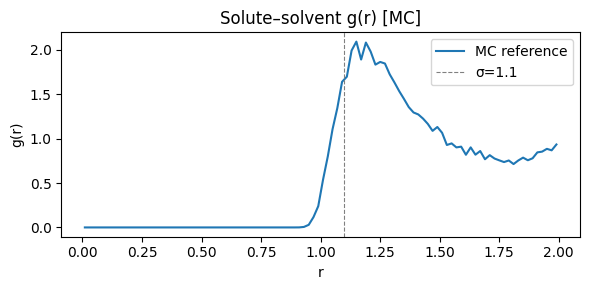

In [7]:
# Radial distribution function g(r): solute–solvent
def compute_gr(traj, l_box, n_bins=100, r_max=None):
    """
    Solute-solvent g(r) from trajectory.

    Parameters
    ----------
    traj  : (N_frames, N, 3)  full system with solute at index 0
    l_box : float             half-box width; full box side L = 2*l_box
    """
    L = 2 * l_box
    if r_max is None:
        r_max = l_box          # maximum meaningful distance with min-image = L/2
    bins = np.linspace(0, r_max, n_bins + 1)
    r_centers = 0.5 * (bins[:-1] + bins[1:])
    hist = np.zeros(n_bins)
    n_frames, N, _ = traj.shape
    # Bulk solvent number density: (N-1) solvent particles / box volume
    rho = (N - 1) / L**3
    for frame in traj[::10]:          # thin for speed
        delta = frame[1:] - frame[0]  # displacement: solvent_i - solute
        delta = delta - L * np.round(delta / L)   # minimum-image
        r = np.linalg.norm(delta, axis=-1)
        h, _ = np.histogram(r, bins=bins)
        hist += h
    n_used = len(traj[::10])
    shell_vols = (4/3) * np.pi * (bins[1:]**3 - bins[:-1]**3)
    # g(r) = <n_solvent(r)> / (rho * V_shell)
    # <n_solvent(r)> = hist / n_used  (1 solute centre per frame)
    gr = hist / (n_used * rho * shell_vols)
    return r_centers, gr

r_ref, gr_ref = compute_gr(xtraj, L_BOX)
plt.figure(figsize=(6, 3))
plt.plot(r_ref, gr_ref, label='MC reference')
plt.axvline(SIGMA, color='gray', ls='--', lw=0.8, label=f'σ={SIGMA}')
plt.xlabel('r'); plt.ylabel('g(r)'); plt.title('Solute–solvent g(r) [MC]')
plt.legend(); plt.tight_layout(); plt.show()

## 3. Training Data Preparation

**No Hungarian reordering** — the equivariant flow handles permutation symmetry.

In [8]:
# Extract solvent only (skip solute at index 0), thin, flatten
# NO Hungarian reordering
stride = 5
x_solvent = xtraj[::stride, 1:, :]          # (n_thinned, 36, 3)
x_samples = x_solvent.reshape(len(x_solvent), -1).astype(np.float32)  # (n, 108)
np.random.shuffle(x_samples)
print(f'Training set: {x_samples.shape}')
print(f'r range: [{np.linalg.norm(x_solvent.reshape(-1,3), axis=-1).min():.2f},'
      f' {np.linalg.norm(x_solvent.reshape(-1,3), axis=-1).max():.2f}]')

Training set: (40001, 108)
r range: [0.66, 3.43]


## 4. Build Equivariant Flow

In [ ]:
from generator import build_egnn_solute_flow_3d

flow = build_egnn_solute_flow_3d(
    system=system,
    n_particles=N_SOLVENT,
    n_blocks=8,
    egnn_hidden=64,
    egnn_layers=3,
    num_bins=8,
    tail_bound=4.0,
    l_box=L_BOX,
    att_heads=4,
)

n_params = sum(p.numel() for p in flow.parameters())
print(f'Flow parameters: {n_params:,}')
print(f'Coupling layers: {len(flow.coupling_layers)}')

# Sanity check: round-trip
with torch.no_grad():
    x_test = torch.tensor(x_samples[:4])
    z, ld_fwd = flow.inverse_generator(x_test)
    x_recon, ld_inv = flow.generator(z)
    err = (x_test - x_recon).abs().max().item()
    print(f'Round-trip error: {err:.2e}  (should be < 1e-4)')

In [ ]:
# Permutation equivariance check
with torch.no_grad():
    x_t = torch.tensor(x_samples[:8])
    log_q_orig = -flow.loss_ML(x_t)  # negative loss = log p per sample

    # Permute solvent particles
    perm = torch.randperm(N_SOLVENT)
    x_perm = x_t.view(8, N_SOLVENT, 3)[:, perm, :].reshape(8, N_SOLVENT*3)
    log_q_perm = -flow.loss_ML(x_perm)

    err_perm = (log_q_orig - log_q_perm).abs().max().item()
    print(f'Permutation equivariance error: {err_perm:.2e}  (should be < 1e-4)')

# Rotation equivariance check
with torch.no_grad():
    # Random SO(3) rotation
    Q, _ = torch.linalg.qr(torch.randn(3, 3))
    if torch.det(Q) < 0:
        Q[:, 0] *= -1
    x_rot = (x_t.view(8, N_SOLVENT, 3) @ Q.T).reshape(8, N_SOLVENT*3)
    log_q_rot = -flow.loss_ML(x_rot)
    err_rot = (log_q_orig - log_q_rot).abs().max().item()
    print(f'Rotation equivariance error:    {err_rot:.2e}  (should be < 1e-3)')

## 5. Stage 1 — ML Training (Forward KL)

In [ ]:
from training import BoltzmannGenerator3D

BG_ml = BoltzmannGenerator3D({
    'n_epochs':   300,
    'LR':         3e-4,
    'batch_size': 256,
    'patience':   40,
    'min_delta':  1e-3,
})

losses_ml = BG_ml.train(
    flow,
    w_loss=[1.0, 0.0],
    x_samples=x_samples,
)

plt.figure(figsize=(6, 3))
plt.plot(losses_ml)
plt.xlabel('epoch'); plt.ylabel('ML loss'); plt.title('Stage 1: ML training')
plt.tight_layout(); plt.show()

## 6. Stage 2 — KL Fine-tuning (Reverse KL)

In [ ]:
z_kl = flow.prior.sample(50_000)

BG_kl = BoltzmannGenerator3D({
    'n_epochs':   100,
    'LR':         3e-5,
    'batch_size': 256,
    'patience':   30,
})

losses_kl = BG_kl.train(
    flow,
    w_loss=[0.1, 0.9],
    x_samples=x_samples,
    z_samples=z_kl,
    energy_cap=500.0,
)

plt.figure(figsize=(6, 3))
plt.plot(losses_kl)
plt.xlabel('epoch'); plt.ylabel('Combined loss'); plt.title('Stage 2: KL fine-tuning')
plt.tight_layout(); plt.show()

## 7. Evaluation

In [ ]:
# Generate samples
with torch.no_grad():
    z_eval = flow.prior.sample(2000)
    x_gen_flat, logdet = flow.generator(z_eval)

x_gen = x_gen_flat.numpy().reshape(-1, N_SOLVENT, 3)   # (2000, 36, 3)

# Prepend solute at origin so compute_gr gets (2000, 37, 3) with solute at index 0
x_gen_full = np.concatenate([np.zeros((len(x_gen), 1, 3)), x_gen], axis=1)

# g(r) comparison
r_gen, gr_gen = compute_gr(x_gen_full, L_BOX)

plt.figure(figsize=(6, 3))
plt.plot(r_ref, gr_ref, label='MC reference')
plt.plot(r_gen, gr_gen, '--', label='Equivariant flow')
plt.axvline(SIGMA, color='gray', ls='--', lw=0.8, label=f'σ={SIGMA}')
plt.xlabel('r'); plt.ylabel('g(r)'); plt.title('Solute–solvent g(r)')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Energy distribution
x_ref_flat = x_samples[:2000]
x_ref_full = np.concatenate([np.zeros((2000, 1, 3)), x_ref_flat.reshape(2000, N_SOLVENT, 3)], axis=1)
# x_gen_full already defined in the cell above (solute prepended)

with torch.no_grad():
    e_ref = system.get_energy_batch(torch.tensor(x_ref_full.reshape(2000, -1))).numpy()
    e_gen = system.get_energy_batch(torch.tensor(x_gen_full.reshape(2000, -1))).numpy()

plt.figure(figsize=(6, 3))
finite_ref = e_ref[np.isfinite(e_ref) & (e_ref < 1e4)]
finite_gen = e_gen[np.isfinite(e_gen) & (e_gen < 1e4)]
plt.hist(finite_ref, bins=50, density=True, alpha=0.5, label='MC')
plt.hist(finite_gen, bins=50, density=True, alpha=0.5, label='Flow')
plt.xlabel('Energy'); plt.ylabel('Density'); plt.title('Energy distribution')
plt.legend(); plt.tight_layout(); plt.show()

print(f'MC   energy: {finite_ref.mean():.1f} ± {finite_ref.std():.1f}')
print(f'Flow energy: {finite_gen.mean():.1f} ± {finite_gen.std():.1f}')
print(f'Flow finite fraction: {len(finite_gen)/2000:.3f}')

In [ ]:
# Minimum pairwise distances (overlap check)
def min_pair_dist(configs, l_box):
    L = 2 * l_box
    N = configs.shape[1]
    mins = []
    for c in configs[::10]:
        diff = c[None] - c[:, None]   # (N, N, 3)
        diff = diff - L * np.round(diff / L)
        r = np.linalg.norm(diff, axis=-1)
        np.fill_diagonal(r, np.inf)
        mins.append(r.min())
    return np.array(mins)

min_r_ref = min_pair_dist(x_ref_full, L_BOX)
min_r_gen = min_pair_dist(x_gen_full, L_BOX)

plt.figure(figsize=(6, 3))
plt.hist(min_r_ref, bins=30, density=True, alpha=0.5, label='MC')
plt.hist(min_r_gen, bins=30, density=True, alpha=0.5, label='Flow')
plt.axvline(SIGMA, color='k', ls='--', label=f'σ={SIGMA}')
plt.xlabel('Min. pairwise distance'); plt.title('Minimum pair distances')
plt.legend(); plt.tight_layout(); plt.show()

overlap_frac = (min_r_gen < 0.8 * SIGMA).mean()
print(f'Fraction of generated configs with overlap (r < 0.8σ): {overlap_frac:.3f}')

## 8. Save Model

In [ ]:
save_dir = _ROOT / 'Notebooks' / 'Trained_models' / 'Solute_PBC_Equivariant'
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'model_egnn_v1'
torch.save(flow.state_dict(), save_path)
print(f'Saved to {save_path}')